In this space we will run k-means clustering on Profession vs. Family_Size.
First we load in all libraries

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

We load in the dataset

In [12]:
df = pd.read_csv("Final_encoded.csv")

We select the columns we wish to use.

In [13]:
df_selected = df[['Profession', 'Family_Size']]

We define the amount of clusters we are looking for.

In [14]:
num_clusters = 3

We initalize the K-Means modeling

In [15]:
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df_selected['Cluster'] = kmeans.fit_predict(df_selected)

/tmp/ipykernel_17905/1069080464.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Cluster'] = kmeans.fit_predict(df_selected)


In [16]:
df_selected.to_csv("Final_encoded_clustered Family vs. Profession.csv", index=False)

We plot inertia for optimal clustering

In [17]:
inertia_values = []
cluster_range = range(1, 10) 

Now we have the clustering ran multiple times to check the best number of clusters

In [18]:
for k in cluster_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(df_selected.drop(columns=['Cluster'], errors='ignore'))
    inertia_values.append(kmeans_test.inertia_)

We plot the outcome for visualization

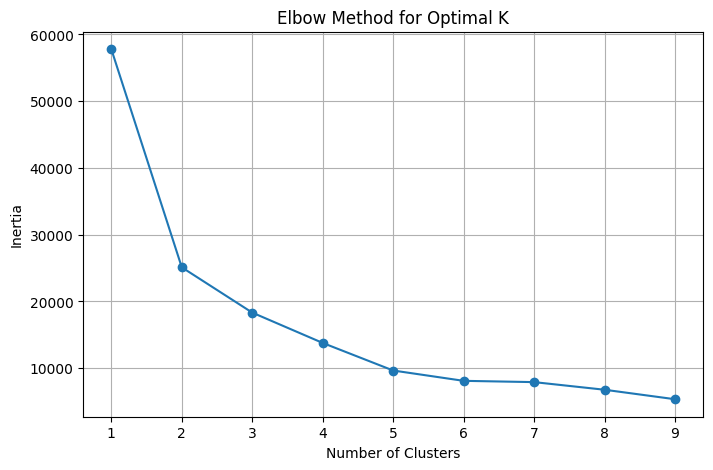

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

We will plot the clusters and create a visulization.

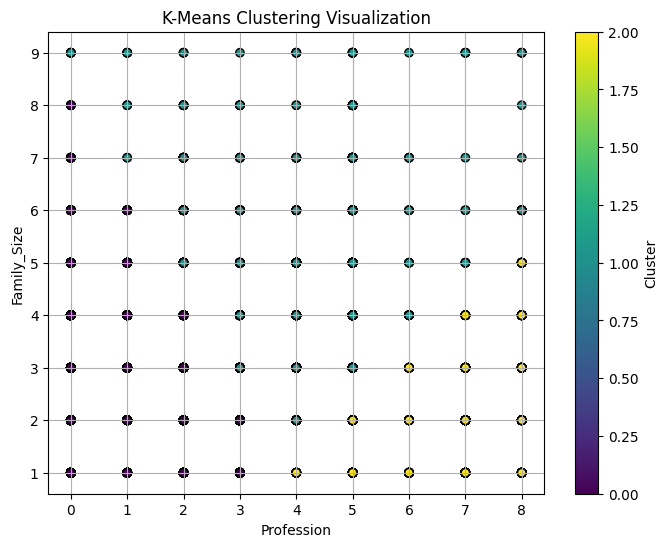

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df_selected['Profession'], df_selected['Family_Size'], c=df_selected['Cluster'], cmap='viridis', edgecolors='k')
plt.xlabel("Profession")
plt.ylabel("Family_Size")
plt.title("K-Means Clustering Visualization")
plt.colorbar(label="Cluster")
plt.grid()
plt.show()